# VNExpress News Data Overview
VNEXpress là một trong những trang báo điện tử lớn nhất tại Việt Nam, cung cấp tin tức về nhiều lĩnh vực như chính trị, kinh tế, xã hội, thể thao, giải trí và công nghệ. Dưới đây là một số thông tin về dữ liệu từ VNExpress:
* 1. Nguồn dữ liệu: VNExpress
* 2. Thời gian thu thập: Từ tháng 1 năm 2026 đến tháng 3 năm 2026
* 3. Các lĩnh vực tin tức: Công nghệ, Khoa học, Sức khoẻ, Thể thao, Giải trí, Chính trị, Kinh tế, Xã hội,...
* 4. Số lượng bài viết: Khoảng 100.000 bài viết

Notebook này thực hiện khảo sát và thống kê sơ bộ dữ liệu thu thập từ VNExpress, tập trung vào hai nhóm bài viết: 
* "Sức khoẻ" và "Giải trí".

## Dữ liệu bao gồm các trường
* `title`: Tiêu đề bài viết
* `description`: Mô tả ngắn gọn 
* `date`: Ngày giờ xuất bản bài viết
* `category`: Thể loại bài viết (Ví dụ: Phim, Nhạc, Hô hấp, Thần kinh,...)
* `thumbnail`: Đường dẫn đến hình ảnh đại diện bài viết
* `content`: Nội dung bài viết
* `author`: Tác giả bài viết
* `tags`: Các thẻ liên quan đến bài viết
* `group`: Danh mục bài viết (Sức khoẻ, Giải trí)
* `nums_of_comments`: Số lượng bình luận bài viết
* `url`: Đường dẫn đến bài viết




## 1. Import các thư viện cần thiết

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import re
from collections import Counter

sns.set(style="whitegrid")

pd.set_option('display.max_columns', None)


## 2. Đọc và tìm hiểu dữ liệu

### 2.1 Đọc dữ liệu từ file CSV

In [49]:
DATA_PATH = "../data/raw_data/"

df = pd.read_csv(DATA_PATH + "vnexpress_raw_data.csv", encoding="utf-8")


# Hiển thị thông tin cơ bản của tập dữ liệu
print("Kích thước dataset:", df.shape)
print("\nThông tin cột:")
df.info()

Kích thước dataset: (1219, 11)

Thông tin cột:
<class 'pandas.DataFrame'>
RangeIndex: 1219 entries, 0 to 1218
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   title             1214 non-null   str  
 1   description       1217 non-null   str  
 2   date              1214 non-null   str  
 3   content           1214 non-null   str  
 4   thumbnail         1219 non-null   str  
 5   author            1219 non-null   str  
 6   tags              1219 non-null   str  
 7   group             1219 non-null   str  
 8   category          1219 non-null   str  
 9   nums_of_comments  1219 non-null   int64
 10  url               1219 non-null   str  
dtypes: int64(1), str(10)
memory usage: 104.9 KB


### 2.2 Xem vài dòng dữ liệu đầu

In [50]:
df.head(3)

,title,description,date,content,thumbnail,author,tags,group,category,nums_of_comments,url
0,Vì sao ăn bánh mì có thể ngộ độc?,"Các nguyên liệu trong bánh mì như pate, thịt n...","Thứ sáu, 6/3/2026, 08:00 (GMT+7)",Từ đầu tháng 3 đến nay miền Nam liên tiếp xảy ...,https://i1-suckhoe.vnecdn.net/2026/03/06/ba-nh...,Quyên Phan,"ngộ độc thực phẩm, bánh mì",Các bệnh,Tiêu hóa,16,https://vnexpress.net/vi-sao-an-banh-mi-co-the...
1,Khám đau cột sống bất ngờ phát hiện hẹp van tim,"TP HCMÔng Sang, 59 tuổi, đau cột sống thắt lưn...","Thứ năm, 5/3/2026, 09:00 (GMT+7)","TS.BS Trần Vũ Minh Thư, Trưởng khoa Nội tim mạ...",https://i1-suckhoe.vnecdn.net/2026/03/05/image...,Thu Hà,"tp hcm, hẹp van tim, khám cột sống, bệnh tim mạch",Các bệnh,Tim mạch,0,https://vnexpress.net/kham-dau-cot-song-bat-ng...
2,"Thời trang đồng điệu của Kỳ Duyên, Đoàn Thiên Ân","Hoa hậu Kỳ Duyên, Thiên Ân thường chọn trang c...","Thứ sáu, 27/2/2026, 08:12 (GMT+7)","Dịp Tết Bính Ngọ, hai hoa hậu dành thời gian d...",https://i1-giaitri.vnecdn.net/2026/02/23/Ky-Du...,Tân Cao,"hoa hậu kỳ duyên, đoàn thiên ân, sao việt diện...",Giải trí,Thời trang,1,https://vnexpress.net/thoi-trang-dong-dieu-cua...


### 2.3 Thông tin các cột dữ liệu

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1219 entries, 0 to 1218
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   title             1214 non-null   str  
 1   description       1217 non-null   str  
 2   date              1214 non-null   str  
 3   content           1214 non-null   str  
 4   thumbnail         1219 non-null   str  
 5   author            1219 non-null   str  
 6   tags              1219 non-null   str  
 7   group             1219 non-null   str  
 8   category          1219 non-null   str  
 9   nums_of_comments  1219 non-null   int64
 10  url               1219 non-null   str  
dtypes: int64(1), str(10)
memory usage: 104.9 KB


### 2.4 Kiểm tra dữ liệu thiếu

In [52]:
missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing (%)": missing_percentage
})

missing_df.sort_values(by="Missing Values", ascending=False)

,Missing Values,Missing (%)
title,5,0.410172
date,5,0.410172
content,5,0.410172
description,2,0.164069
thumbnail,0,0.000000
author,0,0.000000
tags,0,0.000000
group,0,0.000000
category,0,0.000000
nums_of_comments,0,0.000000


### 2.5 Thống kê mô tả cho các cột số

In [53]:
print("Thống kê mô tả cho các cột số:")
df.describe().T

Thống kê mô tả cho các cột số:


,count,mean,std,min,25%,50%,75%,max
nums_of_comments,1219.0,7.579163,18.465721,0.0,0.0,2.0,7.0,206.0


## 3. Phân bố dữ liệu

### 3.1 Số lượng bài viết theo nhóm

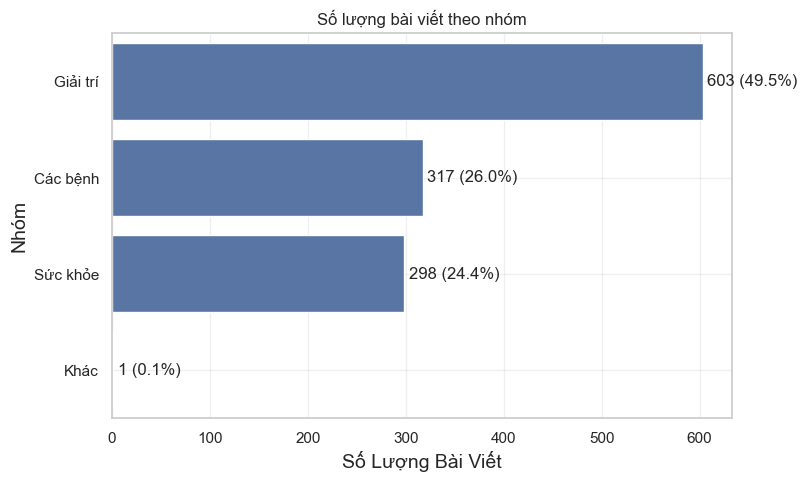

Tổng số bài viết: 1219
- Giải trí: 603 bài viết (49.5%)
- Các bệnh: 317 bài viết (26.0%)
- Sức khỏe: 298 bài viết (24.4%)
- Khác: 1 bài viết (0.1%)


In [54]:
plt.figure(figsize=(8,5))

group_counts = df["group"].value_counts()

sns.barplot(
    y=group_counts.index,
    x=group_counts.values
)

plt.title("Số lượng bài viết theo nhóm")
plt.xlabel('Số Lượng Bài Viết', fontsize=14)
plt.ylabel('Nhóm', fontsize=14)
plt.grid(True, alpha=0.3)

# Add count labels on bars
for i, v in enumerate(group_counts.values):
    plt.text(v + 5, i, f"{v} ({v/len(df)*100:.1f}%)", va='center')

plt.show()

# Add text summary below the plot
print(f"Tổng số bài viết: {len(df)}")
for group, count in group_counts.items():
    print(f"- {group}: {count} bài viết ({count/len(df)*100:.1f}%)")

### 3.2 Số lượng bài theo category

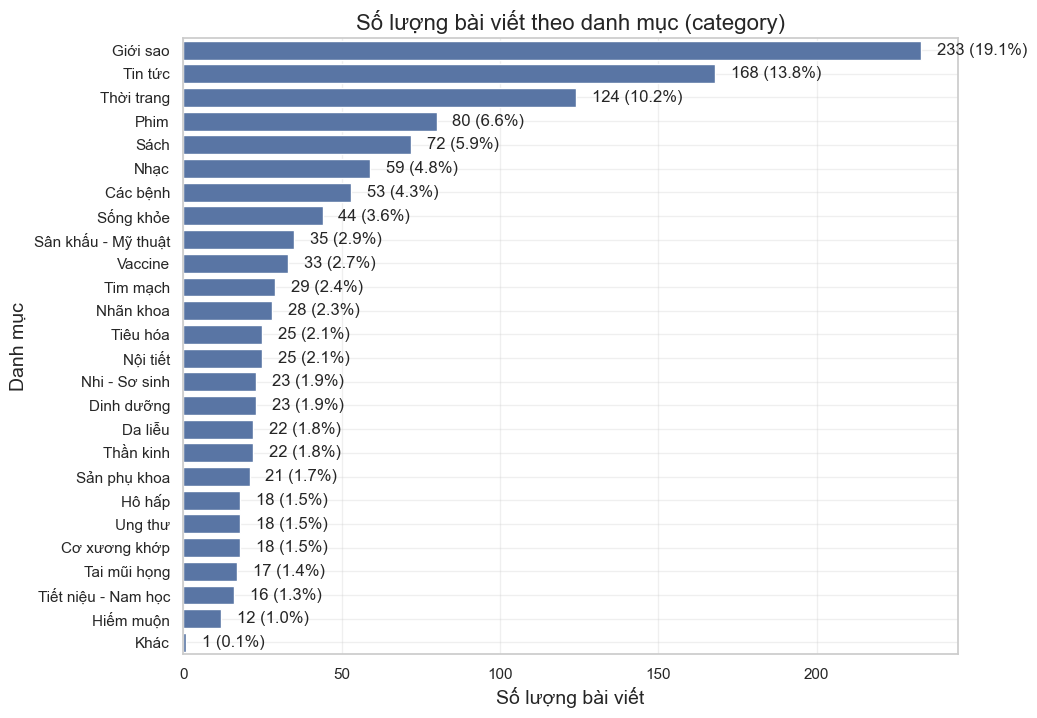

Tổng số bài viết: 1219
- Giới sao: 233 bài viết (19.1%)
- Tin tức: 168 bài viết (13.8%)
- Thời trang: 124 bài viết (10.2%)
- Phim: 80 bài viết (6.6%)
- Sách: 72 bài viết (5.9%)
- Nhạc: 59 bài viết (4.8%)
- Các bệnh: 53 bài viết (4.3%)
- Sống khỏe: 44 bài viết (3.6%)
- Sân khấu - Mỹ thuật: 35 bài viết (2.9%)
- Vaccine: 33 bài viết (2.7%)
- Tim mạch: 29 bài viết (2.4%)
- Nhãn khoa: 28 bài viết (2.3%)
- Tiêu hóa: 25 bài viết (2.1%)
- Nội tiết: 25 bài viết (2.1%)
- Nhi - Sơ sinh: 23 bài viết (1.9%)
- Dinh dưỡng: 23 bài viết (1.9%)
- Da liễu: 22 bài viết (1.8%)
- Thần kinh: 22 bài viết (1.8%)
- Sản phụ khoa: 21 bài viết (1.7%)
- Hô hấp: 18 bài viết (1.5%)
- Ung thư: 18 bài viết (1.5%)
- Cơ xương khớp: 18 bài viết (1.5%)
- Tai mũi họng: 17 bài viết (1.4%)
- Tiết niệu - Nam học: 16 bài viết (1.3%)
- Hiếm muộn: 12 bài viết (1.0%)
- Khác: 1 bài viết (0.1%)


In [55]:
plt.figure(figsize=(10, 8))
category_counts = df['category'].value_counts()
sns.barplot(y=category_counts.index, x=category_counts.values)
plt.title('Số lượng bài viết theo danh mục (category)', fontsize=16)
plt.xlabel('Số lượng bài viết', fontsize=14)
plt.ylabel('Danh mục', fontsize=14)
plt.grid(True, alpha=0.3)

# Add count labels on bars
for i, v in enumerate(category_counts.values):
    plt.text(v + 5, i, f"{v} ({v/len(df)*100:.1f}%)", va='center')

plt.show()

# Add text summary below the plot
print(f"Tổng số bài viết: {len(df)}")
for category, count in category_counts.items():
    print(f"- {category}: {count} bài viết ({count/len(df)*100:.1f}%)")

## 4. Nhận xét về dữ liệu raw

Qua quá trình phân tích dữ liệu thô:

- Dataset gồm các bài viết từ hai chuyên mục:
  - Sức khỏe
  - Giải trí

- Một số vấn đề phát hiện:
  - Tồn tại dữ liệu trống
  - Phân loại nhóm chưa chuẩn 
  - Định dạng ngày chưa chuẩn
  - Văn bản chưa được chuẩn hóa
  - Có thể có bài trùng lặp

→ Vì vậy cần bước **data cleaning** để:
- Xử lý dữ liệu bị trống
- Chuẩn hóa văn bản
- Chuẩn hoá phân loại nhóm cho từng bài viét
- Chuẩn hóa thời gian
- Loại bỏ trùng lặp (duplicate)

## 5. Xác định định hướng bài toán phù hợp dữ liệu

Từ dữ liệu này có thể xây dựng các bài toán:

### Hướng 1: Dự đoán số lượng bình luận (nums_of_comments)

* Mục tiêu: Dự đoán số lượng bình luận bài viết.

* Vấn đề: Phân phối số bình luận lệch, có nhiều ngoại lệ (outliers). Trung bình là 7.57 nhưng trung vị chỉ 2, số liệu lệch phải quá mạnh. 

* Khó khăn: Cần xử lý ngoại lệ, phân phối lệch (log-transform) và dữ liệu thiếu. Mô hình hồi quy có thể khó dự đoán chính xác.

* Kết luận: Không thực sự khả thi, độ chính xác thấp.
    
### Hướng 2: Phân loại bài viết thành Sức khoẻ / Giải trí (group)

* Mục tiêu: Dự đoán bài viết thuộc nhóm Sức khoẻ hay Giải trí.

* Ưu điểm: Dữ liệu không bị lệch, có thể sử dụng các đặc trưng văn bản như title, content, tags. Các mô hình phân loại như SVM, Random Forest hoặc Deep Learning có thể áp dụng tốt.

* Khả thi: Dễ dàng xây dựng mô hình phân loại, với ứng dụng thực tế cao trong việc phân loại bài viết tự động.

* Kết luận: Bài toán phân loại Sức khoẻ / Giải trí khả thi hơn, dễ triển khai và có ứng dụng thực tế cao.

### Lựa chọn cuối cùng:

Chọn bài toán phân loại Sức khoẻ / Giải trí vì tính khả thi và ứng dụng thực tế cao hơn so với bài toán hồi quy dự đoán số bình luận.